# COMBINED DATA FIGURE 

In [49]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import cv2

from scipy.ndimage import gaussian_filter
from pathlib import Path

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## The *Present* DS1

In [2]:
#### Read in data 
present_df = pd.read_csv('present_ds1_df.csv')
present_df = present_df.iloc[:, 1:]
print(present_df.head())
print(present_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          564.2          631.6 -1.122725  sub-A00010201
1          564.3          630.9 -1.117170  sub-A00010201
2          564.5          629.8 -1.111614  sub-A00010201
3          564.7          628.0 -1.106058  sub-A00010201
4          564.3          628.4 -1.100503  sub-A00010201
(7500629, 4)


In [ ]:
### descriptive stats 
present_number_subjects = len(present_df['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(present_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in present_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* FILTERED

In [3]:
### present
# x
present_mean_x = present_df['x_corr_pixels'].mean()
present_sd_x = present_df['x_corr_pixels'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df['x_corr_pixels'].min()} and max x: {present_df['x_corr_pixels'].max()}")
print(f"present number of samples: {len(present_df)}")

# filter out oultiers 
present_df_filtered = present_df[
    (present_df['x_corr_pixels'] <= present_upper_x) &
    (present_df['x_corr_pixels'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df_filtered['x_corr_pixels'].mean()}, x_min: {present_df_filtered['x_corr_pixels'].min()}, x_max: {present_df_filtered['x_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df['y_corr_pixels'].mean()
present_sd_y = present_df['y_corr_pixels'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df['y_corr_pixels'].min()} and max y: {present_df['y_corr_pixels'].max()}")

# filter out outliers 
present_df_filtered = present_df_filtered[
    (present_df_filtered['y_corr_pixels'] <= present_upper_y) &
    (present_df_filtered['y_corr_pixels'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df_filtered['y_corr_pixels'].mean()}, y_min: {present_df_filtered['y_corr_pixels'].min()}, y_max: {present_df_filtered['y_corr_pixels'].max()}")
print(f"Filter present number of samples lost: {len(present_df)-len(present_df_filtered)}")
print(f"Filter present number of subjects: {len(present_df['subjectID'].unique())}")

present x_corr mean: 653.1171967844298 and std: 82.66069334043692
present x_corr upper: 859.768930135522 and lower: 446.4654634333375
present x_corr min x: -3160.4 and max x: 3147.4
present number of samples: 7500629
Filter present mean x: 654.9725570006368, x_min: 446.5, x_max: 859.7
Filter present number of samples lost: 136106
**************************************************
present y_corr mean: 410.2976534234662 and std: 127.21930195190917
present y_corr upper: 728.3459083032392 and lower: 92.2493985436933
present y_corr min y: -3263.3 and max y: 3275.8
Filtered present mean y: 405.2632955712474, y_min: 92.3, y_max: 728.3
Filter present number of samples lost: 285279
Filter present number of subjects: 192


### The *Present* Plot RAW data 

In [ ]:
plt.plot(present_df['times'], present_df['x_corr_pixels'])
plt.title("RAW Present: x_corr_pixels x Time")
plt.show()

plt.plot(present_df_filtered['times'], present_df_filtered['x_corr_pixels'])
plt.ylim(-500,1500)
plt.title("FILTERED Present: x_corr_pixels x Time")
plt.show()


### The *Present* STANDARIZED

In [4]:
# present 
present_df_standard = present_df_filtered
x_min_present = present_df_filtered['x_corr_pixels'].min()
x_max_present = present_df_filtered['x_corr_pixels'].max()
present_df_standard['x_norm'] = (present_df_standard['x_corr_pixels'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df_standard, 'x_norm')

print("*"*50)

y_min_present = present_df_filtered['y_corr_pixels'].min()
y_max_present = present_df_filtered['y_corr_pixels'].max()
present_df_standard['y_norm'] = (present_df_standard['y_corr_pixels'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.503631
min     0.000000
max     1.000000
std     0.147825
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.492081
min     0.000000
max     1.000000
std     0.159880
Name: y_norm, dtype: float64


## The *Present* DS2

In [5]:
#### Read in data 
present_df2 = pd.read_csv('present_ds2_right_eye_df.csv')
present_df2 = present_df2.iloc[:, 1:]
print(present_df2.head())
print(present_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  629.099976  518.599976 -1.367178  sub-A00008326
1  629.700012  519.400024 -1.365070  sub-A00008326
2  629.700012  519.400024 -1.363065  sub-A00008326
3  627.400024  524.000000 -1.361112  sub-A00008326
4  623.799988  529.200012 -1.359141  sub-A00008326
(12527062, 4)


In [ ]:
### descriptive stats 
present_number_subjects = len(present_df2['subjectID'].unique())
print(f"Number of subjects in PRESENT: {present_number_subjects}")

xx = descr_stats(present_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(present_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in present_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: PRESENT data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### The *Present* DS2 FILTERED 

In [6]:
### present
# x
present_mean_x = present_df2['rightEyeX'].mean()
present_sd_x = present_df2['rightEyeX'].std()
print(f"present x_corr mean: {present_mean_x} and std: {present_sd_x}")
present_upper_x = present_mean_x + (present_sd_x*2.5)
present_lower_x = present_mean_x - (present_sd_x*2.5)
print(f"present x_corr upper: {present_upper_x} and lower: {present_lower_x}")
print(f"present x_corr min x: {present_df2['rightEyeX'].min()} and max x: {present_df2['rightEyeX'].max()}")
print(f"present number of samples: {len(present_df2)}")

# filter out oultiers 
present_df2_filtered = present_df2[
    (present_df2['rightEyeX'] <= present_upper_x) &
    (present_df2['rightEyeX'] >= present_lower_x)
]
print(f"Filter present mean x: {present_df2_filtered['rightEyeX'].mean()}, x_min: {present_df2_filtered['rightEyeX'].min()}, x_max: {present_df2_filtered['rightEyeX'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")

print("*"*50)

# y 
present_mean_y = present_df2['rightEyeY'].mean()
present_sd_y = present_df2['rightEyeY'].std()
print(f"present y_corr mean: {present_mean_y} and std: {present_sd_y}")
present_upper_y = present_mean_y + (present_sd_y*2.5)
present_lower_y = present_mean_y - (present_sd_y*2.5)
print(f"present y_corr upper: {present_upper_y} and lower: {present_lower_y}")
print(f"present y_corr min y: {present_df2['rightEyeY'].min()} and max y: {present_df2['rightEyeY'].max()}")

# filter out outliers 
present_df2_filtered = present_df2_filtered[
    (present_df2_filtered['rightEyeY'] <= present_upper_y) &
    (present_df2_filtered['rightEyeY'] >= present_lower_y)
]
print(f"Filtered present mean y: {present_df2_filtered['rightEyeY'].mean()}, y_min: {present_df2_filtered['rightEyeY'].min()}, y_max: {present_df2_filtered['rightEyeY'].max()}")
print(f"Filter present number of samples lost: {len(present_df2)-len(present_df2_filtered)}")
print(f"Filter present number of subjects: {len(present_df2['subjectID'].unique())}")

present x_corr mean: -1927.9169310710067 and std: 8921.628328148188
present x_corr upper: 20376.153889299465 and lower: -24231.987751441477
present x_corr min x: -32768.0 and max x: 2559.699951171875
present number of samples: 12527062
Filter present mean x: 651.4910385655261, x_min: -1279.5999755859375, x_max: 2559.699951171875
Filter present number of samples lost: 966873
**************************************************
present y_corr mean: -2058.0056852035495 and std: 8882.972552968735
present y_corr upper: 20149.42569721829 and lower: -24265.437067625386
present y_corr min y: -32768.0 and max y: 2046.800048828125
Filtered present mean y: 510.52189969408386, y_min: -1023.7000122070312, y_max: 2046.800048828125
Filter present number of samples lost: 966873
Filter present number of subjects: 115


### The *Present* DS2 STANDARIZED 

In [7]:
# present 
present_df2_standard = present_df2_filtered
x_min_present = present_df2_filtered['rightEyeX'].min()
x_max_present = present_df2_filtered['rightEyeX'].max()
present_df2_standard['x_norm'] = (present_df2_standard['rightEyeX'] - x_min_present) / (x_max_present - x_min_present)
x_norm = descr_stats(present_df2_standard, 'x_norm')

print("*"*50)

y_min_present = present_df2_filtered['rightEyeY'].min()
y_max_present = present_df2_filtered['rightEyeY'].max()
present_df2_standard['y_norm'] = (present_df2_standard['rightEyeY'] - y_min_present) / (y_max_present - y_min_present)
y_norm = descr_stats(present_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.502980
min     0.000000
max     1.000000
std     0.058335
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.499665
min     0.000000
max     1.000000
std     0.056453
Name: y_norm, dtype: float64


## Combine *Present* DS1 and DS2

In [8]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
present_df_merge = present_df_standard[cols]
present_df2_merge = present_df2_standard[cols]

present_combined_df = pd.concat([present_df_merge, present_df2_merge])
print(present_combined_df.head())

      times      subjectID    x_norm    y_norm
0 -1.122725  sub-A00010201  0.284850  0.847956
1 -1.117170  sub-A00010201  0.285092  0.846855
2 -1.111614  sub-A00010201  0.285576  0.845126
3 -1.106058  sub-A00010201  0.286060  0.842296
4 -1.100503  sub-A00010201  0.285092  0.842925


## The *Present* PLOT

### Calculate ISC 

In [9]:
df = present_combined_df.copy()

# --- Interpolate onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df = pd.DataFrame(isc_results)
# Rank by ISC_x
isc_df["rank_x"] = isc_df["ISC_x"].rank()  
isc_df["rank_y"] = isc_df["ISC_y"].rank()  
print(isc_df.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_68359/36024446.py:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_68359/36024446.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_y, _ = pearsonr(y_mat[i], y_loo_mean)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_68359/36024446.py:36: RuntimeWarning: Mean of empty slice
  "ISC_mean": np.nanmean([isc_x, isc_y])


       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y
0  sub-A00010201  0.408883  0.770207  0.589545   161.0   296.0
1  sub-A00010893  0.605286  0.716113  0.660699   229.0   280.0
2  sub-A00015273  0.552216  0.064685  0.308451   212.0    81.0
3  sub-A00017133 -0.330732  0.305926 -0.012403    14.0   170.0
4  sub-A00022607 -0.030892  0.209287  0.089197    42.0   139.0


0

#### Merge ISC with present_combined_df

In [10]:
test = present_combined_df.copy()
test = present_combined_df.merge(isc_df[['subjectID', "ISC_x", "ISC_y", 'rank_x', 'rank_y']], on="subjectID")
print(test.head())
# rename to present_combined_df 
present_combined_df = test.copy()
print(present_combined_df.head())

      times      subjectID    x_norm    y_norm     ISC_x     ISC_y  rank_x  \
0 -1.122725  sub-A00010201  0.284850  0.847956  0.408883  0.770207   161.0   
1 -1.117170  sub-A00010201  0.285092  0.846855  0.408883  0.770207   161.0   
2 -1.111614  sub-A00010201  0.285576  0.845126  0.408883  0.770207   161.0   
3 -1.106058  sub-A00010201  0.286060  0.842296  0.408883  0.770207   161.0   
4 -1.100503  sub-A00010201  0.285092  0.842925  0.408883  0.770207   161.0   

   rank_y  
0   296.0  
1   296.0  
2   296.0  
3   296.0  
4   296.0  
      times      subjectID    x_norm    y_norm     ISC_x     ISC_y  rank_x  \
0 -1.122725  sub-A00010201  0.284850  0.847956  0.408883  0.770207   161.0   
1 -1.117170  sub-A00010201  0.285092  0.846855  0.408883  0.770207   161.0   
2 -1.111614  sub-A00010201  0.285576  0.845126  0.408883  0.770207   161.0   
3 -1.106058  sub-A00010201  0.286060  0.842296  0.408883  0.770207   161.0   
4 -1.100503  sub-A00010201  0.285092  0.842925  0.408883  0.770207   

### Fixation X x Time 



#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 1:57 and 2:28
line_times = [117, 148]

# Add vertical dashed red lines
for t in line_times:
    plt.axvline(x=t, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('The Present: Fixation X over Time')

plt.show()

Raw Data

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(present_combined_df["times"], present_combined_df["x_norm"], linewidth=1, color="#2563eb", alpha=0.85)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Standarized X Position", fontsize=12)
ax.set_title("Gaze Position Over Time", fontsize=14)

# ax.set_ylim(0, 1)  # x_norm is typically 0–1; remove if yours differs
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("The Present Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    present_combined_df["times"],
    present_combined_df["rank_x"],
    C=present_combined_df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_x"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_x"].min(),
#                          df["rank_x"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df.loc[isc_df['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,200)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Z-Scored Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

#### Frame x Frame Heatmap

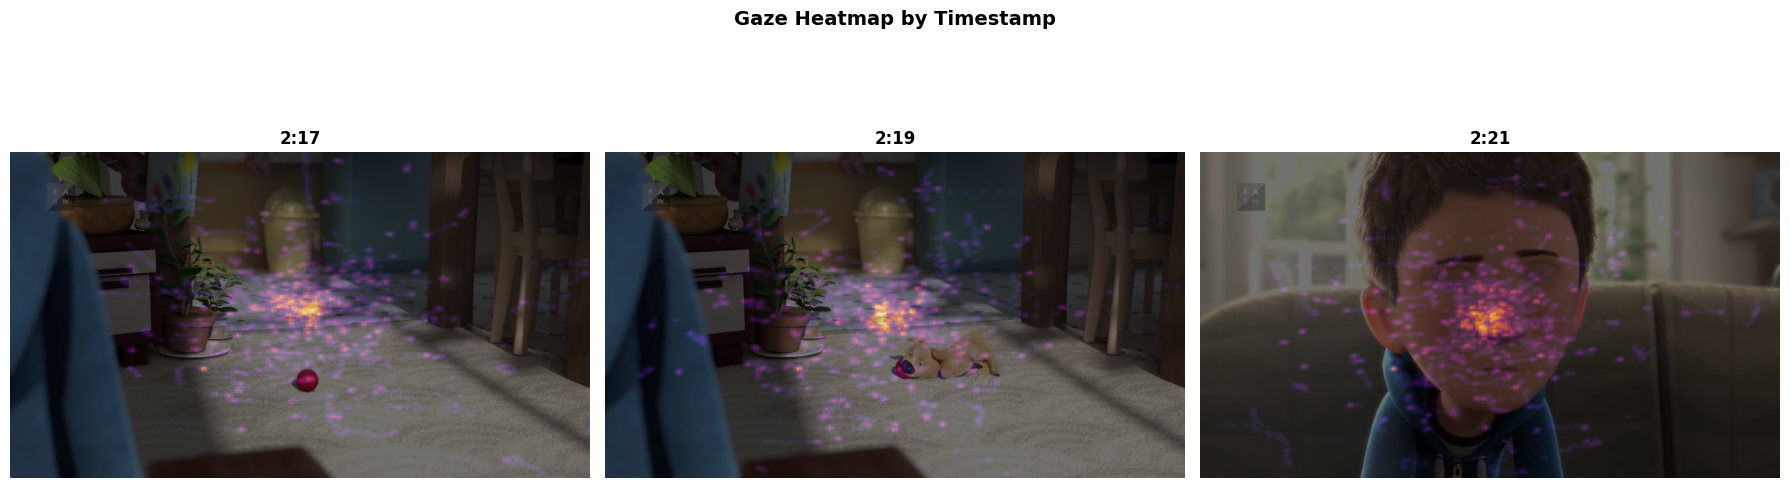

t=137: 16806 rows, 290 subjects
t=139: 17060 rows, 295 subjects
t=141: 17167 rows, 296 subjects
[-40.61234879 -40.60679293 -40.60123706 -40.59568119 -40.59012532
 -40.58456945 -40.57901359 -40.57345772 -40.56790185 -40.56234598
 -40.55679011 -40.55123425 -40.54567838 -40.54012275 -40.53456688
 -40.52901101 -40.52345514 -40.18454766 -40.17899179 -40.17343593]
             x_norm        y_norm
count  1.877554e+07  1.877554e+07
mean   5.032303e-01  4.967505e-01
std    1.024358e-01  1.086237e-01
min    0.000000e+00  0.000000e+00
25%    4.658761e-01  4.601205e-01
50%    5.054307e-01  4.979645e-01
75%    5.458547e-01  5.400749e-01
max    1.000000e+00  1.000000e+00


In [ ]:
# --- Settings ---
VIDEO_PATH = "/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/video_files/thepresent.mp4"
TIMESTAMPS = [137, 139, 141]  
WINDOW = 0.1
ASPECT_RATIO = 16 / 9 
# ASPECT_RATIO = 4 / 3

def extract_frame(video_path, timestamp_sec):
    """Extract a single frame from a video at a given timestamp."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_sec * 1000)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not extract frame at {timestamp_sec}s")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# def make_gaze_heatmap(x_norm, y_norm, frame_shape):
#     h, w = frame_shape[:2]
#     w_corrected = int(h * ASPECT_RATIO)  # CHANGED

#     x_px = x_norm * w_corrected          # CHANGED
#     y_px = y_norm * h

#     xx, yy = np.mgrid[0:w_corrected:200j, h:0:200j]  # CHANGED
#     positions = np.vstack([xx.ravel(), yy.ravel()])
#     values = np.vstack([x_px, y_px])
#     kde = gaussian_kde(values, bw_method=0.08)
#     density = kde(positions).reshape(200, 200).T

#     return density

def make_gaze_heatmap(x_norm, y_norm, frame_shape):
    h, w = frame_shape[:2]
    w_corrected = int(h * ASPECT_RATIO)

    # Work entirely in normalized 0-1 space for KDE
    xx, yy = np.mgrid[0:1:200j, 1:0:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_norm, y_norm])
    kde = gaussian_kde(values, bw_method=0.03)  # now 0.05 means 5% of screen width
    density = kde(positions).reshape(200, 200).T

    return density

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ts in zip(axes, TIMESTAMPS):
    # Extract video frame
    frame = extract_frame(VIDEO_PATH, ts)

    # Filter gaze data to window around timestamp
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ].dropna(subset=["x_norm", "y_norm"])

    # Compute heatmap
    density = make_gaze_heatmap(window_df["x_norm"].values, window_df["y_norm"].values, frame.shape)

    # Plot frame + overlay heatmap
    ax.imshow(frame, extent=[0, frame.shape[1], frame.shape[0], 0])
    ax.imshow(
        density,
        extent=[0, frame.shape[1], frame.shape[0], 0],
        cmap="inferno",
        alpha=0.55,
        norm=mcolors.PowerNorm(gamma=0.4)   # stretch colormap to show sparse gaze too
    )

    mins = ts // 60
    secs = ts % 60
    ax.set_title(f"{mins}:{secs:02d}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Gaze Heatmap by Timestamp", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("gaze_heatmaps.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()


# Trouble shoot 
for ts in TIMESTAMPS:
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ]
    print(f"t={ts}: {len(window_df)} rows, {window_df['subjectID'].nunique()} subjects")

print(present_combined_df["times"].sort_values().unique()[:20])

print(present_combined_df[["x_norm", "y_norm"]].describe())

In [ ]:
TIMESTAMPS = [137, 139, 141]  # 1:46, 1:47, 1:48 in seconds

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ts in zip(axes, TIMESTAMPS):
    window_df = present_combined_df[
        np.isclose(present_combined_df["times"], ts, atol=0.01)
    ].dropna(subset=["x_norm", "y_norm"])

    # KDE over normalized 0-1 space (no pixel conversion needed)
    xx, yy = np.mgrid[0:1:200j, 0:1:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([window_df["x_norm"].values, window_df["y_norm"].values])
    kde = gaussian_kde(values, bw_method=0.08)
    density = kde(positions).reshape(200, 200).T

    ax.imshow(
        density,
        origin="upper",
        extent=[0, 1, 1, 0],
        cmap="hot",
        aspect="auto"
    )

    mins, secs = ts // 60, ts % 60
    ax.set_title(f"{mins}:{secs:02d}", fontsize=12, fontweight="bold")
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Gaze Heatmap by Timestamp", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

#### NEW Frame by Frame

Video bounds in normalized coords:
  X: [0.1667, 0.8333]
  Y: [0.2593, 0.9259]
t=137s | window=1.0s | 84278 samples total | 81209 inside video (96.4%) | 294 subjects
t=139s | window=1.0s | 85190 samples total | 80892 inside video (95.0%) | 299 subjects
t=141s | window=1.0s | 85246 samples total | 81000 inside video (95.0%) | 296 subjects


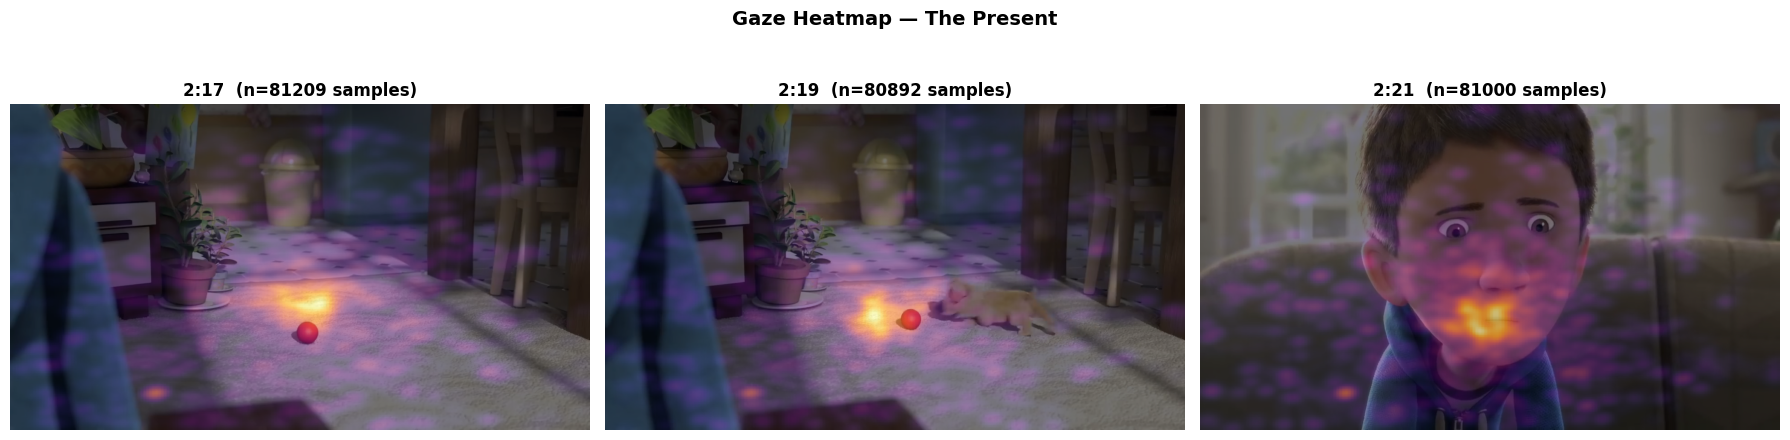


── x_norm / y_norm summary ──
             x_norm        y_norm
count  1.877554e+07  1.877554e+07
mean   5.032000e-01  4.968000e-01
std    1.024000e-01  1.086000e-01
min    0.000000e+00  0.000000e+00
25%    4.659000e-01  4.601000e-01
50%    5.054000e-01  4.980000e-01
75%    5.459000e-01  5.401000e-01
max    1.000000e+00  1.000000e+00

── Fraction of samples inside video bounds ──
  17866831 / 18775539 (95.2%)


In [59]:
"""
Gaze Heatmap on Video Frames — corrected for windowed video
-------------------------------------------------------------
Screen:  1920 x 1080
Video:   1280 x 720, centered on screen
         → left edge at x = (1920-1280)/2 = 320  (as proportion: 320/1920 = 0.1667)
         → top  edge at y = (1080-720)/2  = 180  (as proportion: 180/1080 = 0.1667)
         → right edge at x = 1600/1920 = 0.8333
         → bottom edge at y = 900/1080  = 0.8333
"""
# ── 0. SCREEN / VIDEO GEOMETRY ────────────────────────────────────────────────

SCREEN_W, SCREEN_H = 1920, 1080
VIDEO_W,  VIDEO_H  = 1280, 720

# Video offset in pixels
OFFSET_X = (SCREEN_W - VIDEO_W) // 2   # 320px
# OFFSET_Y = (SCREEN_H - VIDEO_H) // 2   # 180px
OFFSET_Y = 280

# Video bounds in normalized screen coordinates [0, 1]
VIDEO_X_MIN = OFFSET_X / SCREEN_W      # 0.1667
VIDEO_X_MAX = (OFFSET_X + VIDEO_W) / SCREEN_W   # 0.8333
VIDEO_Y_MIN = OFFSET_Y / SCREEN_H      # 0.1667
VIDEO_Y_MAX = (OFFSET_Y + VIDEO_H) / SCREEN_H   # 0.8333

print(f"Video bounds in normalized coords:")
print(f"  X: [{VIDEO_X_MIN:.4f}, {VIDEO_X_MAX:.4f}]")
print(f"  Y: [{VIDEO_Y_MIN:.4f}, {VIDEO_Y_MAX:.4f}]")

# ── 1. SETTINGS ───────────────────────────────────────────────────────────────

VIDEO_PATH = "/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/video_files/thepresent.mp4"
TIMESTAMPS = [137, 139, 141]
WINDOW     = 0.5        # seconds either side of timestamp — increase if heatmap looks sparse
BW_METHOD  = 0.08       # KDE bandwidth — smaller = tighter clusters


# ── 2. HELPERS ────────────────────────────────────────────────────────────────

def extract_frame(video_path, timestamp_sec):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_sec * 1000)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not extract frame at {timestamp_sec}s")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def remap_to_video(x_norm, y_norm):
    """
    Remap gaze from normalized screen coords [0,1] 
    to normalized video coords [0,1].
    
    Drops samples that fall outside the video window.
    """
    mask = (
        (x_norm >= VIDEO_X_MIN) & (x_norm <= VIDEO_X_MAX) &
        (y_norm >= VIDEO_Y_MIN) & (y_norm <= VIDEO_Y_MAX)
    )
    x_video = (x_norm[mask] - VIDEO_X_MIN) / (VIDEO_X_MAX - VIDEO_X_MIN)
    y_video = (y_norm[mask] - VIDEO_Y_MIN) / (VIDEO_Y_MAX - VIDEO_Y_MIN)
    return x_video, y_video, mask

# def remap_to_video(x_norm, y_norm):
#     y_norm_flipped = 1 - y_norm   # flip y before remapping
#     mask = (
#         (x_norm       >= VIDEO_X_MIN) & (x_norm       <= VIDEO_X_MAX) &
#         (y_norm_flipped >= VIDEO_Y_MIN) & (y_norm_flipped <= VIDEO_Y_MAX)
#     )
#     x_video = (x_norm[mask]        - VIDEO_X_MIN) / (VIDEO_X_MAX - VIDEO_X_MIN)
#     y_video = (y_norm_flipped[mask] - VIDEO_Y_MIN) / (VIDEO_Y_MAX - VIDEO_Y_MIN)
#     return x_video, y_video, mask


def make_gaze_heatmap(x_video_norm, y_video_norm, bw=BW_METHOD, grid_size=200):
    """
    Build KDE heatmap in video-normalized [0,1] coords.
    Returns density grid of shape (grid_size, grid_size).
    """
    if len(x_video_norm) < 2:
        return np.zeros((grid_size, grid_size))

    xx, yy    = np.mgrid[0:1:complex(0, grid_size), 1:0:complex(0, grid_size)]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values    = np.vstack([x_video_norm, y_video_norm])
    kde       = gaussian_kde(values, bw_method=bw)
    density   = kde(positions).reshape(grid_size, grid_size).T
    return density


# ── 3. PLOT ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(TIMESTAMPS), figsize=(6 * len(TIMESTAMPS), 5))
if len(TIMESTAMPS) == 1:
    axes = [axes]

for ax, ts in zip(axes, TIMESTAMPS):

    # Extract frame
    frame = extract_frame(VIDEO_PATH, ts)
    h, w  = frame.shape[:2]

    # Filter gaze window
    window_df = present_combined_df[
        (present_combined_df["times"] >= ts - WINDOW) &
        (present_combined_df["times"] <= ts + WINDOW)
    ].dropna(subset=["x_norm", "y_norm"])

    # Remap to video coordinates
    x_vid, y_vid, mask = remap_to_video(
        window_df["x_norm"].values,
        window_df["y_norm"].values
    )

    n_total  = len(window_df)
    n_in_vid = mask.sum()
    print(f"t={ts}s | window={WINDOW*2:.1f}s | {n_total} samples total | "
          f"{n_in_vid} inside video ({n_in_vid/n_total*100:.1f}%) | "
          f"{window_df['subjectID'].nunique()} subjects")

    # Build heatmap
    density = make_gaze_heatmap(x_vid, y_vid)

    # Plot frame — extent maps image to pixel coords
    ax.imshow(frame, extent=[0, w, h, 0])

    # Overlay heatmap — same extent as frame
    ax.imshow(
        density,
        extent=[0, w, h, 0],
        cmap="inferno",
        alpha=0.55,
        norm=mcolors.PowerNorm(gamma=0.4),
        origin="upper"
    )

    mins, secs = divmod(ts, 60)
    ax.set_title(f"{mins}:{secs:02d}  (n={n_in_vid} samples)", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Gaze Heatmap — The Present", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("gaze_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()


# ── 4. DIAGNOSTIC: check gaze coverage ───────────────────────────────────────

print("\n── x_norm / y_norm summary ──")
print(present_combined_df[["x_norm", "y_norm"]].describe().round(4))

print(f"\n── Fraction of samples inside video bounds ──")
in_bounds = (
    present_combined_df["x_norm"].between(VIDEO_X_MIN, VIDEO_X_MAX) &
    present_combined_df["y_norm"].between(VIDEO_Y_MIN, VIDEO_Y_MAX)
)
print(f"  {in_bounds.sum()} / {len(present_combined_df)} "
      f"({in_bounds.mean()*100:.1f}%)")

In [51]:
print(present_combined_df.columns)

Index(['times', 'subjectID', 'x_norm', 'y_norm', 'ISC_x', 'ISC_y', 'rank_x',
       'rank_y', 'r', 'r_deriv', 'ISC_rderiv', 'rank_rderiv', 'time_bin'],
      dtype='object')


### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    present_combined_df['times'],
    present_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-25, 230)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('The Present: Fixation Y over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(present_combined_df["times"].min(), present_combined_df["times"].max(), 300)

present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = present_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

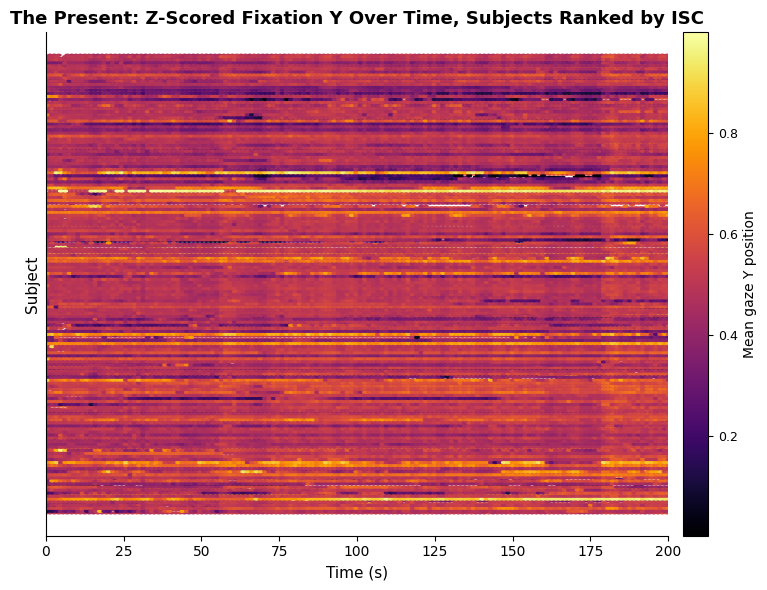

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    present_combined_df["times"],
    present_combined_df["rank_y"],
    C=present_combined_df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df.loc[isc_df['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# shorten graph 
plt.xlim(0,200)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Z-Scored Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Polar Derivative 

#### Calculate Polar Derivative

In [12]:
"""
Polar Coordinate Distance Derivative
-------------------------------------
Computes radial distance from screen center and its time derivative
for combined (both trackers) normalized gaze data.

Input columns: times, subjectID, x_norm, y_norm, time_bin
Output: adds r (radial distance) and r_deriv (derivative) columns
"""
# ── 1. COMPUTE POLAR DISTANCE ─────────────────────────────────────────────────
# Reference point = screen center in normalized coordinates

x_ref = 0.5
y_ref = 0.5

present_combined_df["r"] = np.sqrt(
    (present_combined_df["x_norm"] - x_ref) ** 2 +
    (present_combined_df["y_norm"] - y_ref) ** 2
)

# ── 2. COMPUTE DERIVATIVE PER SUBJECT ────────────────────────────────────────
# np.gradient uses central differences — robust at interior points,
# one-sided differences at the edges.
# We sort by time within each subject to ensure correct ordering.

present_combined_df = present_combined_df.sort_values(
    ["subjectID", "times"]
).reset_index(drop=True)

present_combined_df["r_deriv"] = (
    present_combined_df
    .groupby("subjectID")["r"]
    .transform(lambda s: np.gradient(s.values, s.index))
)

# ── 3. SANITY CHECKS ──────────────────────────────────────────────────────────

print("── Radial distance (r) ──")
print(present_combined_df["r"].describe().round(4))

print("\n── Derivative (r_deriv) ──")
print(present_combined_df["r_deriv"].describe().round(4))

# Flag any subjects with suspiciously large derivatives (likely residual outliers)
subj_max_deriv = (
    present_combined_df
    .groupby("subjectID")["r_deriv"]
    .apply(lambda s: s.abs().quantile(0.99))
    .sort_values(ascending=False)
)
print("\n── 99th percentile |r_deriv| per subject (top 10) ──")
print(subj_max_deriv.head(10).round(4))

# ── 4. OPTIONAL: CLIP EXTREME DERIVATIVES ────────────────────────────────────
# If residual outliers are causing spikes in r_deriv, clip at a threshold.
# Inspect the distribution first before uncommenting.

# deriv_threshold = present_combined_df["r_deriv"].abs().quantile(0.99)
# present_combined_df["r_deriv"] = present_combined_df["r_deriv"].clip(
#     -deriv_threshold, deriv_threshold
# )
# print(f"\nClipped r_deriv to ±{deriv_threshold:.4f}")

print("\nDone. New columns added: 'r', 'r_deriv'")
print(present_combined_df[["subjectID", "times", "x_norm", "y_norm", "r", "r_deriv"]].head(10))

── Radial distance (r) ──
count    1.877554e+07
mean     1.083000e-01
std      1.028000e-01
min      0.000000e+00
25%      3.770000e-02
50%      6.880000e-02
75%      1.466000e-01
max      7.059000e-01
Name: r, dtype: float64

── Derivative (r_deriv) ──
count    1.877554e+07
mean    -0.000000e+00
std      5.000000e-03
min     -2.703000e-01
25%     -2.000000e-04
50%      0.000000e+00
75%      2.000000e-04
max      3.050000e-01
Name: r_deriv, dtype: float64

── 99th percentile |r_deriv| per subject (top 10) ──
subjectID
sub-A00065995    0.1069
sub-A00058952    0.0990
sub-A00018181    0.0744
sub-A00065992    0.0584
sub-A00060603    0.0448
sub-A00081243    0.0436
sub-A00082734    0.0435
sub-A00051456    0.0424
sub-A00054019    0.0411
sub-A00083732    0.0396
Name: r_deriv, dtype: float64

Done. New columns added: 'r', 'r_deriv'
       subjectID     times    x_norm    y_norm         r   r_deriv
0  sub-A00008326 -1.367178  0.497148  0.502296  0.003661  0.000054
1  sub-A00008326 -1.365070  0.4

#### Calculate new ISC with Polar Derivative 

In [13]:
df = present_combined_df.copy()

# --- Interpolate r_deriv onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

r_mat = []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    r_mat.append(np.interp(time_grid, d['times'], d['r_deriv']))

r_mat = np.array(r_mat)  # shape: (n_subjects, n_timepoints)

n = len(subjects)

# --- Vectorized LOO mean
r_sum = r_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    r_loo_mean = (r_sum - r_mat[i]) / (n - 1)
    isc_r, _   = pearsonr(r_mat[i], r_loo_mean)

    isc_results.append({
        "subjectID" : subj,
        "ISC_rderiv": isc_r,
    })

isc_rderiv_df = pd.DataFrame(isc_results)
isc_rderiv_df["rank_rderiv"] = isc_rderiv_df["ISC_rderiv"].rank()

print(isc_rderiv_df.describe().round(4))
print(isc_rderiv_df.sort_values("ISC_rderiv", ascending=False).head(10))
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_68359/1685701725.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_r, _   = pearsonr(r_mat[i], r_loo_mean)


       ISC_rderiv  rank_rderiv
count    304.0000     304.0000
mean       0.0368     152.5000
std        0.3425      87.9015
min       -0.9038       1.0000
25%       -0.0689      76.7500
50%        0.0075     152.5000
75%        0.1058     228.2500
max        0.8252     304.0000
         subjectID  ISC_rderiv  rank_rderiv
62   sub-A00040594    0.825170        304.0
106  sub-A00055332    0.820099        303.0
101  sub-A00054578    0.818472        302.0
58   sub-A00040301    0.817051        301.0
186  sub-A00074429    0.814854        300.0
20   sub-A00031452    0.808110        299.0
132  sub-A00060503    0.804967        298.0
185  sub-A00074113    0.799635        297.0
296  sub-A00088405    0.797352        296.0
249  sub-A00081385    0.797080        295.0


0

Merge new ISC ranks with present_combined_df

In [14]:
test = present_combined_df.copy()
# print(test.head())
test = test.merge(isc_rderiv_df[['subjectID', 'ISC_rderiv', 'rank_rderiv']], on='subjectID')
# print(test.head())
present_combined_df = test.copy()
print(present_combined_df.head())

      times      subjectID    x_norm    y_norm     ISC_x     ISC_y  rank_x  \
0 -1.367178  sub-A00008326  0.497148  0.502296 -0.315178  0.288652    16.0   
1 -1.365070  sub-A00008326  0.497304  0.502557 -0.315178  0.288652    16.0   
2 -1.363065  sub-A00008326  0.497304  0.502557 -0.315178  0.288652    16.0   
3 -1.361112  sub-A00008326  0.496705  0.504055 -0.315178  0.288652    16.0   
4 -1.359141  sub-A00008326  0.495767  0.505748 -0.315178  0.288652    16.0   

   rank_y         r   r_deriv  ISC_rderiv  rank_rderiv  
0   167.0  0.003661  0.000054     0.01756        164.0  
1   167.0  0.003715  0.000027     0.01756        164.0  
2   167.0  0.003715  0.000755     0.01756        164.0  
3   167.0  0.005225  0.001712     0.01756        164.0  
4   167.0  0.007138  0.000957     0.01756        164.0  


#### Plot Polar Derivate with ISC 

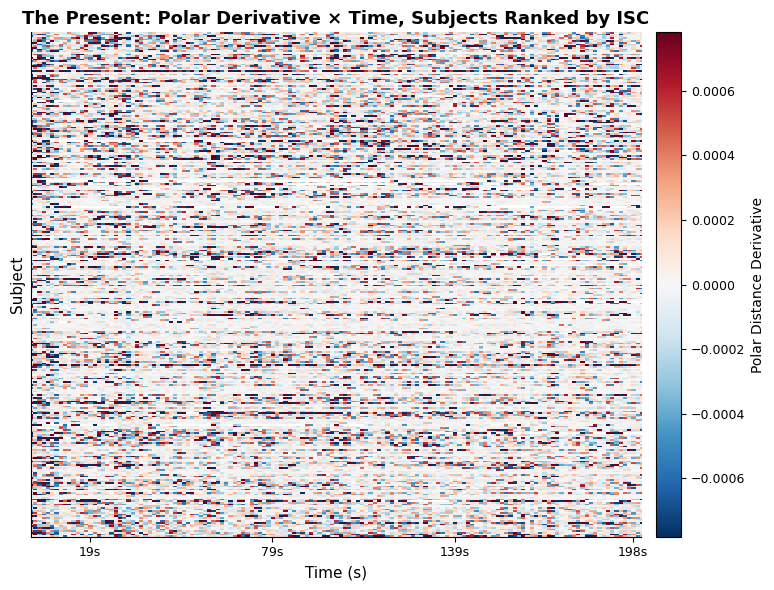

In [28]:
# ── Step 3: Pivot to subject × time_bin matrix ───────────────────────────────
# time_bin should already be in your present_combined_df; if not:
present_combined_df["time_bin"] = pd.cut(present_combined_df["times"], bins=300, labels=False)

pivot = (
    present_combined_df.groupby(["rank_rderiv", "time_bin"])["r_deriv"]
    .mean()
    .unstack(level="time_bin")   # rows = subjects (ranked), cols = time bins
)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Symmetric colormap centered at 0
vmax = np.nanpercentile(np.abs(pivot.values), 95)  # robust, ignores extreme spikes

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",                          # rank 1 at bottom
    cmap="RdBu_r",                           # diverging: red=moving away, blue=moving toward center
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest"
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Polar Distance Derivative", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Axes ──────────────────────────────────────────────────────────────────────
# Map time bin indices back to seconds for x ticks
time_bins  = pivot.columns.values
time_vals  = present_combined_df.groupby("time_bin")["times"].mean().reindex(time_bins).values
n_ticks    = 8
tick_idx   = np.linspace(0, len(time_bins) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{time_vals[i]:.0f}s" for i in tick_idx], fontsize=9)

# # Y axis: show ISC values at a few tick positions
# n_yticks    = 6
# subj_ranks  = pivot.index.values
# ytick_idx   = np.linspace(0, len(subj_ranks) - 1, n_yticks, dtype=int)
# ytick_ranks = subj_ranks[ytick_idx]
# ytick_labels = [
#     f"{present_combined_df.loc[present_combined_df['rank_rderiv'] == r, 'ISC_rderiv'].values[0]:.2f}"
#     for r in ytick_ranks
# ]
# ax.set_yticks(ytick_idx)
# ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis:
start_time = -1
end_time = 201

start_idx = np.argmin(np.abs(time_vals - start_time))
end_idx   = np.argmin(np.abs(time_vals - end_time))

ax.set_xlim(start_idx, end_idx)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Present: Polar Derivative × Time, Subjects Ranked by ISC",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("polar_deriv_raster.png", dpi=300, bbox_inches="tight")
plt.show()

## *Sherlock* DS1

In [29]:
### read in data 
sherlock_df = pd.read_csv("sherlock_ds1_df.csv")
sherlock_df = sherlock_df.iloc[:, 1:]
print(sherlock_df.head())
print(sherlock_df.shape)

   x_corr_pixels  y_corr_pixels     times      subjectID
0          669.9          513.0 -0.405907  sub-A00010201
1          669.9          512.3 -0.400351  sub-A00010201
2          670.0          511.9 -0.394795  sub-A00010201
3          670.1          511.2 -0.389240  sub-A00010201
4          670.0          510.8 -0.383684  sub-A00010201
(20762676, 4)


In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df, 'x_corr_pixels')
print("*"*10)
yy = descr_stats(sherlock_df, 'y_corr_pixels')

In [ ]:
records = []

for subj, grp in sherlock_df.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["x_corr_pixels"].values
    y     = grp["y_corr_pixels"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["x_corr_pixels", "y_corr_pixels"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

# print("=" * 70)
# print("PER-SUBJECT AUDIT SUMMARY: SHERLOCK data_structure_1")
# print("=" * 70)
# print(audit.to_string(index=False))
sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* FILTERED

In [30]:
### sherlock
# x
sherlock_mean_x = sherlock_df['x_corr_pixels'].mean()
sherlock_sd_x = sherlock_df['x_corr_pixels'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df['x_corr_pixels'].min()} and max x: {sherlock_df['x_corr_pixels'].max()}")
print(f"sherlock number of samples: {len(sherlock_df)}")

# filter out oultiers 
sherlock_df_filtered = sherlock_df[
    (sherlock_df['x_corr_pixels'] <= sherlock_upper_x) &
    (sherlock_df['x_corr_pixels'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df_filtered['x_corr_pixels'].mean()}, x_min: {sherlock_df_filtered['x_corr_pixels'].min()}, x_max: {sherlock_df_filtered['x_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df['y_corr_pixels'].mean()
sherlock_sd_y = sherlock_df['y_corr_pixels'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df['y_corr_pixels'].min()} and max y: {sherlock_df['y_corr_pixels'].max()}")

# filter out outliers 
sherlock_df_filtered = sherlock_df_filtered[
    (sherlock_df_filtered['y_corr_pixels'] <= sherlock_upper_y) &
    (sherlock_df_filtered['y_corr_pixels'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df_filtered['y_corr_pixels'].mean()}, y_min: {sherlock_df_filtered['y_corr_pixels'].min()}, y_max: {sherlock_df_filtered['y_corr_pixels'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df)-len(sherlock_df_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df['subjectID'].unique())}")

sherlock x_corr mean: 631.713533414479 and std: 128.22012334351132
sherlock x_corr upper: 952.2638417732574 and lower: 311.1632250557007
sherlock x_corr min x: -3213.2 and max x: 3210.4
sherlock number of samples: 20762676
Filter sherlock mean x: 640.4973818277572, x_min: 311.2, x_max: 952.2
Filter sherlock number of samples lost: 536543
**************************************************
sherlock y_corr mean: 400.64234996972453 and std: 215.7046180931074
sherlock y_corr upper: 939.903895202493 and lower: -138.619195263044
sherlock y_corr min y: -3276.7 and max y: 3276.7
Filtered sherlock mean y: 395.54509381764166, y_min: -138.6, y_max: 939.9
Filter sherlock number of samples lost: 814722
Filter sherlock number of subjects: 192


### *Sherlock* STANDARIZED

In [31]:
# sherlock 
sherlock_df_standard = sherlock_df_filtered
x_min_sherlock = sherlock_df_filtered['x_corr_pixels'].min()
x_max_sherlock = sherlock_df_filtered['x_corr_pixels'].max()
sherlock_df_standard['x_norm'] = (sherlock_df_standard['x_corr_pixels'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df_filtered['y_corr_pixels'].min()
y_max_sherlock = sherlock_df_filtered['y_corr_pixels'].max()
sherlock_df_standard['y_norm'] = (sherlock_df_standard['y_corr_pixels'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.516158
min     0.000000
max     1.000000
std     0.128598
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.495267
min     0.000000
max     1.000000
std     0.109302
Name: y_norm, dtype: float64


## *Sherlock* DS2

In [32]:
### read in data 
sherlock_df2 = pd.read_csv("sherlock_ds2_right_eye_df.csv")
sherlock_df2 = sherlock_df2.iloc[:, 1:]
print(sherlock_df2.head())
print(sherlock_df2.shape)

    rightEyeX   rightEyeY     times      subjectID
0  884.000000  529.299988 -1.433650  sub-A00008326
1  895.900024  519.099976 -1.433295  sub-A00008326
2  897.099976  507.399994 -1.431131  sub-A00008326
3  896.400024  507.600006 -1.429064  sub-A00008326
4  896.500000  506.799988 -1.427053  sub-A00008326
(35309166, 4)


In [ ]:
### descriptive stats 
sherlock_number_subjects = len(sherlock_df2['subjectID'].unique())
print(f"Number of subjects in SHERLOCK: {sherlock_number_subjects}")

xx = descr_stats(sherlock_df2, 'rightEyeX')
print("*"*10)
yy = descr_stats(sherlock_df2, 'rightEyeY')

In [ ]:
records = []

for subj, grp in sherlock_df2.groupby("subjectID"):
    grp = grp.sort_values("times").reset_index(drop=True)
    # print("group variable:", grp)

    times = grp["times"].values
    x     = grp["rightEyeX"].values
    y     = grp["rightEyeY"].values

    # ── Sample rate
    diffs       = np.diff(times)
    median_dt   = np.median(diffs)
    sample_rate = 1.0 / median_dt if median_dt > 0 else np.nan

    # ── Data loss: NaN + zeros (common tracker placeholder)
    n_total     = len(grp)
    n_nan       = grp[["rightEyeX", "rightEyeY"]].isna().any(axis=1).sum()
    n_zero      = ((x == 0) & (y == 0)).sum()
    n_missing   = n_nan + n_zero
    pct_missing = n_missing / n_total * 100

    # ── Coordinate ranges
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)

    # ── Gaze velocity (px/s) — robust noise indicator
    dx       = np.diff(x)
    dy       = np.diff(y)
    dist     = np.sqrt(dx**2 + dy**2)
    velocity = dist / diffs                        # px/s
    vel_median = np.nanmedian(velocity)
    vel_sd     = np.nanstd(velocity)
    vel_p95    = np.nanpercentile(velocity, 95)

    # ── Timestamp regularity (jitter)
    dt_sd    = np.std(diffs) * 1000                # ms jitter

    records.append({
        "subjectID"     : subj,
        "n_samples"     : n_total,
        "sample_rate_hz": round(sample_rate, 1),
        "dt_jitter_ms"  : round(dt_sd, 3),
        "pct_missing"   : round(pct_missing, 2),
        "x_min"         : round(x_min, 1),
        "x_max"         : round(x_max, 1),
        "y_min"         : round(y_min, 1),
        "y_max"         : round(y_max, 1),
        "x_range"       : round(x_max - x_min, 1),
        "y_range"       : round(y_max - y_min, 1),
        "vel_median_pxs": round(vel_median, 1),
        "vel_sd_pxs"    : round(vel_sd, 1),
        "vel_p95_pxs"   : round(vel_p95, 1),
    })

audit = pd.DataFrame(records).sort_values("x_min").reset_index(drop=True)

sampling_rate = descr_stats(audit, 'sample_rate_hz')
x_min = descr_stats(audit, 'x_min')
y_min = descr_stats(audit, 'y_min')
unique_hz = audit['sample_rate_hz'].unique().tolist()
print(f"unique sampling rate in sample: {unique_hz}")

### *Sherlock* DS2 FILTERED 

In [33]:
### sherlock
# x
sherlock_mean_x = sherlock_df2['rightEyeX'].mean()
sherlock_sd_x = sherlock_df2['rightEyeX'].std()
print(f"sherlock x_corr mean: {sherlock_mean_x} and std: {sherlock_sd_x}")
sherlock_upper_x = sherlock_mean_x + (sherlock_sd_x*2.5)
sherlock_lower_x = sherlock_mean_x - (sherlock_sd_x*2.5)
print(f"sherlock x_corr upper: {sherlock_upper_x} and lower: {sherlock_lower_x}")
print(f"sherlock x_corr min x: {sherlock_df2['rightEyeX'].min()} and max x: {sherlock_df2['rightEyeX'].max()}")
print(f"sherlock number of samples: {len(sherlock_df2)}")

# filter out oultiers 
sherlock_df2_filtered = sherlock_df2[
    (sherlock_df2['rightEyeX'] <= sherlock_upper_x) &
    (sherlock_df2['rightEyeX'] >= sherlock_lower_x)
]
print(f"Filter sherlock mean x: {sherlock_df2_filtered['rightEyeX'].mean()}, x_min: {sherlock_df2_filtered['rightEyeX'].min()}, x_max: {sherlock_df2_filtered['rightEyeX'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")

print("*"*50)

# y 
sherlock_mean_y = sherlock_df2['rightEyeY'].mean()
sherlock_sd_y = sherlock_df2['rightEyeY'].std()
print(f"sherlock y_corr mean: {sherlock_mean_y} and std: {sherlock_sd_y}")
sherlock_upper_y = sherlock_mean_y + (sherlock_sd_y*2.5)
sherlock_lower_y = sherlock_mean_y - (sherlock_sd_y*2.5)
print(f"sherlock y_corr upper: {sherlock_upper_y} and lower: {sherlock_lower_y}")
print(f"sherlock y_corr min y: {sherlock_df2['rightEyeY'].min()} and max y: {sherlock_df2['rightEyeY'].max()}")

# filter out outliers 
sherlock_df2_filtered = sherlock_df2_filtered[
    (sherlock_df2_filtered['rightEyeY'] <= sherlock_upper_y) &
    (sherlock_df2_filtered['rightEyeY'] >= sherlock_lower_y)
]
print(f"Filtered sherlock mean y: {sherlock_df2_filtered['rightEyeY'].mean()}, y_min: {sherlock_df2_filtered['rightEyeY'].min()}, y_max: {sherlock_df2_filtered['rightEyeY'].max()}")
print(f"Filter sherlock number of samples lost: {len(sherlock_df2)-len(sherlock_df2_filtered)}")
print(f"Filter sherlock number of subjects: {len(sherlock_df2['subjectID'].unique())}")

sherlock x_corr mean: -3345.0310948690626 and std: 10809.838242761169
sherlock x_corr upper: 23679.564512033856 and lower: -30369.626701771984
sherlock x_corr min x: -32768.0 and max x: 2560.0
sherlock number of samples: 35309166
Filter sherlock mean x: 623.9862897855583, x_min: -1279.300048828125, x_max: 2560.0
Filter sherlock number of samples lost: 4196896
**************************************************
sherlock y_corr mean: -3488.437896503501 and std: 10755.604139147972
sherlock y_corr upper: 23400.57245136643 and lower: -30377.44824437343
sherlock y_corr min y: -32768.0 and max y: 2047.800048828125
Filtered sherlock mean y: 461.23459842907783, y_min: -1023.5999755859376, y_max: 2047.800048828125
Filter sherlock number of samples lost: 4196896
Filter sherlock number of subjects: 115


### *Sherlock* DS2 STANDARIZED

In [34]:
# sherlock 
sherlock_df2_standard = sherlock_df2_filtered
x_min_sherlock = sherlock_df2_filtered['rightEyeX'].min()
x_max_sherlock = sherlock_df2_filtered['rightEyeX'].max()
sherlock_df2_standard['x_norm'] = (sherlock_df2_standard['rightEyeX'] - x_min_sherlock) / (x_max_sherlock - x_min_sherlock)
x_norm = descr_stats(sherlock_df2_standard, 'x_norm')

print("*"*50)

y_min_sherlock = sherlock_df2_filtered['rightEyeY'].min()
y_max_sherlock = sherlock_df2_filtered['rightEyeY'].max()
sherlock_df2_standard['y_norm'] = (sherlock_df2_standard['rightEyeY'] - y_min_sherlock) / (y_max_sherlock - y_min_sherlock)
y_norm = descr_stats(sherlock_df2_standard, 'y_norm')

Summary stats for column: x_norm
mean    0.495738
min     0.000000
max     1.000000
std     0.074622
Name: x_norm, dtype: float64
**************************************************
Summary stats for column: y_norm
mean    0.483439
min     0.000000
max     1.000000
std     0.067912
Name: y_norm, dtype: float64


## Combine *Sherlock* DS1 and DS2

In [35]:
cols = ['times', 'subjectID', 'x_norm', 'y_norm']
sherlock_df_merge = sherlock_df_standard[cols]
sherlock_df2_merge = sherlock_df2_standard[cols]

sherlock_combined_df = pd.concat([sherlock_df_merge, sherlock_df2_merge])
print(sherlock_combined_df.head())


      times      subjectID    x_norm    y_norm
0 -0.405907  sub-A00010201  0.559594  0.604172
1 -0.400351  sub-A00010201  0.559594  0.603523
2 -0.394795  sub-A00010201  0.559750  0.603153
3 -0.389240  sub-A00010201  0.559906  0.602503
4 -0.383684  sub-A00010201  0.559750  0.602133


## *Sherlock* PLOT

### Calculate ISC 

In [36]:
df = sherlock_combined_df.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_norm']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_norm']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_df_sherlock = pd.DataFrame(isc_results)
isc_df_sherlock['rank_x'] = isc_df_sherlock['ISC_x'].rank()
isc_df_sherlock['rank_y'] = isc_df_sherlock['ISC_y'].rank()
print(isc_df_sherlock.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

KeyboardInterrupt: 

### Merge sherlock_combined_df with ISC_df

In [ ]:
test = sherlock_combined_df.copy()

### Fixation X x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['x_norm'],
    gridsize=100,
)

# Add lines: 2:04
line_times = [124]

# Add vertical dashed red lines
plt.axvline(x=line_times, color='red', linestyle='--')

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('X position (pixels)')
plt.title('Sherlock: Fixation X over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["x_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized X Position", fontsize=11)
ax.set_title("Sherlock Fixation X x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# # Add lines: 1:57 and 2:28
# ax.axvline(x=117, color='red',linestyle='--')
# ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC 

In [ ]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_x", "rank_x"]], on="subjectID")

fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_x"],
    C=df["x_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze X position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_x"].min(),
#                          df["rank_x"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_x'] == r, 'ISC_x'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis
plt.xlim(0,610)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Sherlock: Z-Scored Fixation X Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Fixation Y x Time

#### Original Heatmap

In [ ]:
plt.figure(figsize=(8, 4))

plt.hexbin(
    sherlock_combined_df['times'],
    sherlock_combined_df['y_norm'],
    gridsize=100,
)

plt.colorbar(label='Density')
plt.xlim(-50,650)
plt.xlabel('Time')
plt.ylabel('Y position (pixels)')
plt.title('Sherlock: Fixation Y over Time')

plt.show()

#### Median and percentile looking

In [ ]:
# --- Time bins & percentiles ---
time_bins = np.linspace(sherlock_combined_df["times"].min(), sherlock_combined_df["times"].max(), 300)

sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=time_bins, labels=time_bins[:-1]).astype(float)

grouped = sherlock_combined_df.groupby("time_bin")["y_norm"]
t = grouped.median().index.values
median = grouped.median()
p10, p25, p75, p90 = grouped.quantile(0.10), grouped.quantile(0.25), grouped.quantile(0.75), grouped.quantile(0.90)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(t, p10, p90, alpha=0.18, color="#2563eb", label="10–90th percentile")
ax.fill_between(t, p25, p75, alpha=0.35, color="#2563eb", label="25–75th percentile")
ax.plot(t, median, color="#2563eb", linewidth=1.8, label="Median")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Normalized Y Position", fontsize=11)
ax.set_title("The Present Fixation Y x Time: whole sample", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1)
# Add lines: 1:57 and 2:28
ax.axvline(x=117, color='red',linestyle='--')
ax.axvline(x=148, color='red',linestyle='--')
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_figure.png", dpi=300, bbox_inches="tight")
plt.show()

#### Ranked by ISC

In [ ]:
df = sherlock_combined_df.merge(isc_df_sherlock[["subjectID", "ISC_y", "rank_y"]], on="subjectID")

fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_y"],
    C=df["y_norm"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Mean gaze Y position", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,610)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Sherlock: Z-Scored Fixation Y Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("gaze_isc_ranked.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("gaze_isc_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

### Polar Derivative 

#### Calculcate Polar Derivative 

In [37]:
"""
Polar Coordinate Distance Derivative
-------------------------------------
Computes radial distance from screen center and its time derivative
for combined (both trackers) normalized gaze data.

Input columns: times, subjectID, x_norm, y_norm, time_bin
Output: adds r (radial distance) and r_deriv (derivative) columns
"""
# ── 1. COMPUTE POLAR DISTANCE ─────────────────────────────────────────────────
# Reference point = screen center in normalized coordinates

x_ref = 0.5
y_ref = 0.5

sherlock_combined_df["r"] = np.sqrt(
    (sherlock_combined_df["x_norm"] - x_ref) ** 2 +
    (sherlock_combined_df["y_norm"] - y_ref) ** 2
)

# ── 2. COMPUTE DERIVATIVE PER SUBJECT ────────────────────────────────────────
# np.gradient uses central differences — robust at interior points,
# one-sided differences at the edges.
# We sort by time within each subject to ensure correct ordering.

sherlock_combined_df = sherlock_combined_df.sort_values(
    ["subjectID", "times"]
).reset_index(drop=True)

sherlock_combined_df["r_deriv"] = (
    sherlock_combined_df
    .groupby("subjectID")["r"]
    .transform(lambda s: np.gradient(s.values, s.index))
)

# ── 3. SANITY CHECKS ──────────────────────────────────────────────────────────

print("── Radial distance (r) ──")
print(sherlock_combined_df["r"].describe().round(4))

print("\n── Derivative (r_deriv) ──")
print(sherlock_combined_df["r_deriv"].describe().round(4))

# Flag any subjects with suspiciously large derivatives (likely residual outliers)
subj_max_deriv = (
    sherlock_combined_df
    .groupby("subjectID")["r_deriv"]
    .apply(lambda s: s.abs().quantile(0.99))
    .sort_values(ascending=False)
)
print("\n── 99th percentile |r_deriv| per subject (top 10) ──")
print(subj_max_deriv.head(10).round(4))

# ── 4. OPTIONAL: CLIP EXTREME DERIVATIVES ────────────────────────────────────
# If residual outliers are causing spikes in r_deriv, clip at a threshold.
# Inspect the distribution first before uncommenting.

# deriv_threshold = sherlock_combined_df["r_deriv"].abs().quantile(0.99)
# sherlock_combined_df["r_deriv"] = sherlock_combined_df["r_deriv"].clip(
#     -deriv_threshold, deriv_threshold
# )
# print(f"\nClipped r_deriv to ±{deriv_threshold:.4f}")

print("\nDone. New columns added: 'r', 'r_deriv'")
print(sherlock_combined_df[["subjectID", "times", "x_norm", "y_norm", "r", "r_deriv"]].head(10))

── Radial distance (r) ──
count    5.106022e+07
mean     1.063000e-01
std      7.950000e-02
min      0.000000e+00
25%      5.610000e-02
50%      8.360000e-02
75%      1.295000e-01
max      7.051000e-01
Name: r, dtype: float64

── Derivative (r_deriv) ──
count    5.106022e+07
mean     0.000000e+00
std      5.200000e-03
min     -3.027000e-01
25%     -2.000000e-04
50%      0.000000e+00
75%      2.000000e-04
max      3.243000e-01
Name: r_deriv, dtype: float64

── 99th percentile |r_deriv| per subject (top 10) ──
subjectID
sub-A00050812    0.1481
sub-A00058952    0.1473
sub-A00035827    0.1220
sub-A00081103    0.0869
sub-A00037545    0.0817
sub-A00018181    0.0629
sub-A00081243    0.0593
sub-A00060923    0.0560
sub-A00059344    0.0538
sub-A00008326    0.0498
Name: r_deriv, dtype: float64

Done. New columns added: 'r', 'r_deriv'
       subjectID     times    x_norm    y_norm         r   r_deriv
0  sub-A00008326 -1.433650  0.563462  0.505600  0.063709  0.002892
1  sub-A00008326 -1.433295  0.5

#### Calculate new ISC with Polar Derivative 

In [41]:
df = sherlock_combined_df.copy()

# --- Interpolate r_deriv onto time grid
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

r_mat = []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    r_mat.append(np.interp(time_grid, d['times'], d['r_deriv']))

r_mat = np.array(r_mat)  # shape: (n_subjects, n_timepoints)

n = len(subjects)

# --- Vectorized LOO mean
r_sum = r_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    r_loo_mean = (r_sum - r_mat[i]) / (n - 1)
    isc_r, _   = pearsonr(r_mat[i], r_loo_mean)

    isc_results.append({
        "subjectID" : subj,
        "ISC_rderiv": isc_r,
    })

isc_rderiv_df = pd.DataFrame(isc_results)
isc_rderiv_df["rank_rderiv"] = isc_rderiv_df["ISC_rderiv"].rank()

print(isc_rderiv_df.describe().round(4))
print(isc_rderiv_df.sort_values("ISC_rderiv", ascending=False).head(10))
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_68359/3093789902.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  isc_r, _   = pearsonr(r_mat[i], r_loo_mean)


       ISC_rderiv  rank_rderiv
count    305.0000     305.0000
mean       0.0040     153.0000
std        0.0893      88.1901
min       -0.4142       1.0000
25%       -0.0391      77.0000
50%        0.0009     153.0000
75%        0.0513     229.0000
max        0.2285     305.0000
         subjectID  ISC_rderiv  rank_rderiv
106  sub-A00055332    0.228497        305.0
188  sub-A00074447    0.220234        304.0
211  sub-A00075898    0.216278        303.0
297  sub-A00088405    0.208230        302.0
166  sub-A00065992    0.206525        301.0
214  sub-A00076586    0.203749        300.0
1    sub-A00010201    0.199978        299.0
302  sub-A00090343    0.189253        298.0
202  sub-A00075361    0.187452        297.0
44   sub-A00039353    0.186715        296.0


0

Merged new ISC with sherlock_combined_df 

In [43]:
test = sherlock_combined_df.copy()
test = test.merge(isc_rderiv_df[['subjectID', 'ISC_rderiv', 'rank_rderiv']], on='subjectID')
print(test.head())
sherlock_combined_df = test.copy()


      times      subjectID    x_norm    y_norm         r   r_deriv  \
0 -1.433650  sub-A00008326  0.563462  0.505600  0.063709  0.002892   
1 -1.433295  sub-A00008326  0.566562  0.502279  0.066601  0.001591   
2 -1.431131  sub-A00008326  0.566874  0.498470  0.066892  0.000054   
3 -1.429064  sub-A00008326  0.566692  0.498535  0.066708 -0.000076   
4 -1.427053  sub-A00008326  0.566718  0.498274  0.066740  0.000968   

   ISC_rderiv  rank_rderiv  
0    0.138675        289.0  
1    0.138675        289.0  
2    0.138675        289.0  
3    0.138675        289.0  
4    0.138675        289.0  


#### Plot Polar Derivate with ISC 

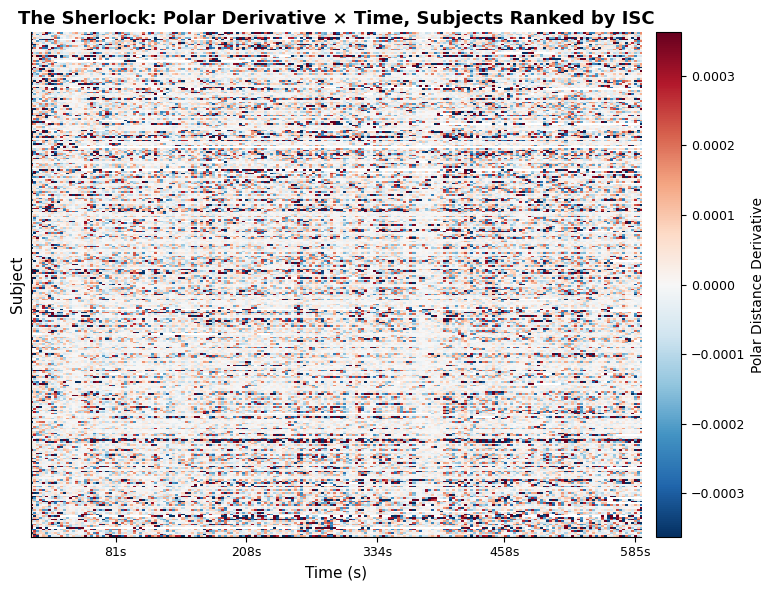

In [46]:
# ── Step 3: Pivot to subject × time_bin matrix ───────────────────────────────
# time_bin should already be in your sherlock_combined_df; if not:
sherlock_combined_df["time_bin"] = pd.cut(sherlock_combined_df["times"], bins=300, labels=False)

pivot = (
    sherlock_combined_df.groupby(["rank_rderiv", "time_bin"])["r_deriv"]
    .mean()
    .unstack(level="time_bin")   # rows = subjects (ranked), cols = time bins
)

# ── Step 4: Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Symmetric colormap centered at 0
vmax = np.nanpercentile(np.abs(pivot.values), 95)  # robust, ignores extreme spikes

im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="lower",                          # rank 1 at bottom
    cmap="RdBu_r",                           # diverging: red=moving away, blue=moving toward center
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest"
)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Polar Distance Derivative", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Axes ──────────────────────────────────────────────────────────────────────
# Map time bin indices back to seconds for x ticks
time_bins  = pivot.columns.values
time_vals  = sherlock_combined_df.groupby("time_bin")["times"].mean().reindex(time_bins).values
n_ticks    = 8
tick_idx   = np.linspace(0, len(time_bins) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"{time_vals[i]:.0f}s" for i in tick_idx], fontsize=9)

# # Y axis: show ISC values at a few tick positions
# n_yticks    = 6
# subj_ranks  = pivot.index.values
# ytick_idx   = np.linspace(0, len(subj_ranks) - 1, n_yticks, dtype=int)
# ytick_ranks = subj_ranks[ytick_idx]
# ytick_labels = [
#     f"{sherlock_combined_df.loc[sherlock_combined_df['rank_rderiv'] == r, 'ISC_rderiv'].values[0]:.2f}"
#     for r in ytick_ranks
# ]
# ax.set_yticks(ytick_idx)
# ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis:
start_time = -1
end_time = 590

start_idx = np.argmin(np.abs(time_vals - start_time))
end_idx   = np.argmin(np.abs(time_vals - end_time))

ax.set_xlim(start_idx, end_idx)

ax.set_xlabel("Time (s)", fontsize=11)
# ax.set_ylabel("ISC Score (ranked)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("The Sherlock: Polar Derivative × Time, Subjects Ranked by ISC",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
# plt.savefig("polar_deriv_raster.png", dpi=300, bbox_inches="tight")
plt.show()